# Results Aggregation

Collects all `partial_result_{n}_{seed}.csv` files, averages over seeds, computes
standard errors (SE = std / sqrt(num_seeds)), and produces a LaTeX table.

**Method mapping:**
- `distinct_clusters` (3 clusters, no fusion) → **EB-PCA**
- `clustered` (2 clusters, intermediate fusion) → **DAIF**
- `same_cluster` (1 cluster, complete fusion) → **OrchAMP**

**Table format:** `mean(se)` — e.g. `0.047(0.003)`. Bold = best mean per column.

In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Latex

# ---------------------------------------------------------------
# Configuration
# ---------------------------------------------------------------
RESULTS_DIR    = "../Results/vary_n"
os.makedirs(RESULTS_DIR, exist_ok=True)
PLOTS_DIR      = "../Plots"
os.makedirs(PLOTS_DIR, exist_ok=True)
OUTPUT_CSV     = "output_func_n_setup_1.csv"
OUTPUT_TEX     = "results_table.tex"

N_VALUES       = [3000, 3500, 4000, 4500, 5000]
NUM_MODALITIES = 3
NUM_TRIALS     = 50    # expected seeds per n

# Internal strategy names -> display names (order = table row order)
STRATEGY_LABELS = {
    "distinct_clusters": "EB-PCA",    # no fusion   (3 clusters)
    "clustered":         "DAIF",      # intermediate (2 clusters, auto CKA)
    "same_cluster":      "OrchAMP",   # full fusion  (1 cluster)
}

os.makedirs(PLOTS_DIR, exist_ok=True)

In [2]:
# ---------------------------------------------------------------
# Load all partial results
# ---------------------------------------------------------------
pattern = os.path.join(RESULTS_DIR, "partial_result_*.csv")
files   = glob.glob(pattern)

if not files:
    raise FileNotFoundError(f"No partial result files found in {RESULTS_DIR}")

print(f"Found {len(files)} partial result files.")
df_all = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)
print(f"Total rows: {len(df_all)}")
df_all.head()

Found 250 partial result files.
Total rows: 750


,n,seed,trial,strategy,modality_1,modality_2,modality_3,cluster_correct
0,3000,48,48,clustered,0.016907,0.016948,0.004430,1.0
1,3000,48,48,same_cluster,0.018255,0.017906,0.027727,NaN
2,3000,48,48,distinct_clusters,0.067023,0.027139,0.004430,NaN
3,4000,17,17,clustered,0.009366,0.013692,0.004643,1.0
4,4000,17,17,same_cluster,0.010970,0.015241,0.027542,NaN


In [3]:
# ---------------------------------------------------------------
# Check completeness — warn about missing (n, seed) combinations
# ---------------------------------------------------------------
print("Completeness check:")
for n in N_VALUES:
    df_n    = df_all[df_all["n"] == n]
    n_seeds = df_n["seed"].nunique()
    status  = "OK" if n_seeds >= NUM_TRIALS else f"WARNING: only {n_seeds}/{NUM_TRIALS} seeds"
    print(f"  n={n}: {n_seeds} seeds — {status}")

Completeness check:
  n=3000: 50 seeds — OK
  n=3500: 50 seeds — OK
  n=4000: 50 seeds — OK
  n=4500: 50 seeds — OK
  n=5000: 50 seeds — OK


In [4]:
# ---------------------------------------------------------------
# Aggregate: mean and SE (std / sqrt(n_trials)) per (n, strategy, modality)
# ---------------------------------------------------------------

# summary[n][strategy] = {
#   'mean': [m1, m2, m3],
#   'se':   [se1, se2, se3]
# }
summary = {}

for n in sorted(df_all['n'].unique()):
    df_n = df_all[df_all['n'] == n]
    summary[n] = {}
    for strategy in STRATEGY_LABELS:
        df_s     = df_n[df_n['strategy'] == strategy]
        n_trials = len(df_s)  # number of seeds/trials for this (n, strategy)
        means = [df_s[f'modality_{i+1}'].mean() for i in range(NUM_MODALITIES)]
        ses   = [df_s[f'modality_{i+1}'].std() / np.sqrt(n_trials) for i in range(NUM_MODALITIES)]
        summary[n][strategy] = {'mean': means, 'se': ses}

# Quick sanity print
for n, strats in summary.items():
    print(f'n={n}:')
    for s, vals in strats.items():
        means_r = [round(v, 4) for v in vals['mean']]
        ses_r   = [round(v, 4) for v in vals['se']]
        print(f'  {STRATEGY_LABELS[s]:10s}: mean={means_r}  se={ses_r}')


n=3000:
  EB-PCA    : mean=[np.float64(0.0573), np.float64(0.0227), np.float64(0.0051)]  se=[np.float64(0.0009), np.float64(0.0022), np.float64(0.0001)]
  DAIF      : mean=[np.float64(0.0123), np.float64(0.0146), np.float64(0.0051)]  se=[np.float64(0.0004), np.float64(0.0003), np.float64(0.0001)]
  OrchAMP   : mean=[np.float64(0.0147), np.float64(0.0172), np.float64(0.0311)]  se=[np.float64(0.0012), np.float64(0.0011), np.float64(0.0005)]
n=3500:
  EB-PCA    : mean=[np.float64(0.0575), np.float64(0.0215), np.float64(0.0053)]  se=[np.float64(0.001), np.float64(0.0022), np.float64(0.0002)]
  DAIF      : mean=[np.float64(0.0123), np.float64(0.0143), np.float64(0.0053)]  se=[np.float64(0.0004), np.float64(0.0003), np.float64(0.0002)]
  OrchAMP   : mean=[np.float64(0.0144), np.float64(0.0166), np.float64(0.0313)]  se=[np.float64(0.0012), np.float64(0.0011), np.float64(0.0004)]
n=4000:
  EB-PCA    : mean=[np.float64(0.0558), np.float64(0.0224), np.float64(0.0051)]  se=[np.float64(0.001), np.

In [5]:
# ---------------------------------------------------------------
# Cluster recovery proportion — DAIF only
# Proportion of trials where DAIF recovers the correct partition:
#   modalities 1 & 2 in the same cluster, modality 3 separate.
# Requires cluster_correct column (added in vary_n.py >= current version).
# ---------------------------------------------------------------
if "cluster_correct" not in df_all.columns:
    print("WARNING: 'cluster_correct' column not found — rerun jobs with updated vary_n.py.")
    df_cluster_recovery = None
else:
    df_daif = df_all[df_all["strategy"] == "clustered"].copy()

    recovery = (
        df_daif.groupby("n")["cluster_correct"]
        .agg(proportion="mean", n_trials="count", std="std")
        .reset_index()
    )
    recovery["se"] = recovery["std"] / np.sqrt(recovery["n_trials"])
    recovery = recovery.drop(columns="std")

    print("DAIF cluster recovery proportion (correct = modalities {1,2} together, 3 separate):")
    display(recovery)

    recovery.to_csv("cluster_recovery.csv", index=False)
    print("Saved cluster_recovery.csv")

DAIF cluster recovery proportion (correct = modalities {1,2} together, 3 separate):


,n,proportion,n_trials,se
0,3000,1.0,50,0.0
1,3500,1.0,50,0.0
2,4000,1.0,50,0.0
3,4500,1.0,50,0.0
4,5000,1.0,50,0.0


Saved cluster_recovery.csv


In [6]:
# ---------------------------------------------------------------
# Save flat summary CSV with mean and SE
# ---------------------------------------------------------------
rows = []
for n, strats in summary.items():
    for strategy, vals in strats.items():
        row = {'n': n, 'method': STRATEGY_LABELS[strategy], 'strategy': strategy}
        for i in range(NUM_MODALITIES):
            row[f'modality_{i+1}_mean'] = vals['mean'][i]
            row[f'modality_{i+1}_se']   = vals['se'][i]
        rows.append(row)

df_summary = pd.DataFrame(rows)
df_summary.to_csv(OUTPUT_CSV, index=False)
print(f'Saved {OUTPUT_CSV}')
df_summary


Saved output_func_n_setup_1.csv


,n,method,strategy,modality_1_mean,modality_1_se,modality_2_mean,modality_2_se,modality_3_mean,modality_3_se
0,3000,EB-PCA,distinct_clusters,0.057285,0.000926,0.022686,0.002227,0.005146,0.000121
1,3000,DAIF,clustered,0.012309,0.000408,0.014631,0.000262,0.005146,0.000121
2,3000,OrchAMP,same_cluster,0.014729,0.001232,0.017195,0.001142,0.031101,0.000465
3,3500,EB-PCA,distinct_clusters,0.057547,0.001023,0.021534,0.002159,0.005286,0.000161
4,3500,DAIF,clustered,0.012250,0.000419,0.014255,0.000289,0.005286,0.000161
5,3500,OrchAMP,same_cluster,0.014352,0.001165,0.016584,0.001148,0.031350,0.000445
6,4000,EB-PCA,distinct_clusters,0.055799,0.000961,0.022413,0.002145,0.005066,0.000123
7,4000,DAIF,clustered,0.011302,0.000420,0.014253,0.000307,0.005066,0.000123
8,4000,OrchAMP,same_cluster,0.013964,0.001190,0.017061,0.001164,0.031709,0.000507
9,4500,EB-PCA,distinct_clusters,0.055214,0.000863,0.015541,0.000644,0.004885,0.000083


In [7]:
# ---------------------------------------------------------------
# Build LaTeX table with SE in parentheses: 0.047(0.003)
#
# Format: mean(se) where se = std / sqrt(n_trials)
# Bold = best (lowest) mean per column within each modality block.
# ---------------------------------------------------------------

def build_latex_table(summary, n_values, strategy_labels, num_modalities):
    """
    Build a LaTeX booktabs table with mean(se) entries.
    Best mean per column is bolded — bold wraps both mean and SE.
    """
    n_cols   = len(n_values)
    col_spec = 'l' + 'r' * n_cols
    col_headers = ' & '.join([f'$n = {n}$' for n in n_values])

    lines = []
    lines.append(r'\begin{table}[ht]')
    lines.append(r'\centering')
    lines.append(r'\begin{tabular}{' + col_spec + '}')
    lines.append(r'\toprule')
    lines.append(f'Method & {col_headers} \\\\')
    lines.append(r'\midrule')

    for mod_idx in range(num_modalities):
        lines.append(
            r'\multicolumn{' + str(n_cols + 1) + r'}{l}{\textbf{Modality '
            + str(mod_idx + 1)
            + r' $(\mathcal{E}_' + str(mod_idx + 1) + r')$}} \\'
        )

        # Collect means to determine bold (best = lowest mean)
        col_means = {
            s: [summary[n][s]['mean'][mod_idx] for n in n_values]
            for s in strategy_labels
        }
        col_mins = [
            min(col_means[s][col] for s in strategy_labels)
            for col in range(n_cols)
        ]

        for strategy, label in strategy_labels.items():
            cells = []
            for col, n in enumerate(n_values):
                mean = summary[n][strategy]['mean'][mod_idx]
                se   = summary[n][strategy]['se'][mod_idx]
                # Format: 0.047(0.003)
                cell = f'{mean:.3f}({se:.3f})'
                if abs(mean - col_mins[col]) < 1e-9:
                    cell = r'\textbf{' + cell + '}'
                cells.append(cell)
            lines.append(label + ' & ' + ' & '.join(cells) + r' \\')

        if mod_idx < num_modalities - 1:
            lines.append(r'\midrule')

    lines.append(r'\bottomrule')
    lines.append(r'\end{tabular}')
    lines.append(
        r'\caption{Average reconstruction error $\mathcal{E}_k$ per modality '
        r'across sample sizes (mean with standard error in parentheses). '
        r'\textbf{EB-PCA}: no fusion (3 clusters); '
        r'\textbf{DAIF}: intermediate fusion (2 clusters, CKA clustering); '
        r'\textbf{OrchAMP}: complete fusion (1 cluster). '
        r'Bold = best mean per column.}'
    )
    lines.append(r'\label{tab:reconstruction_error}')
    lines.append(r'\end{table}')

    return '\n'.join(lines)


n_values_present = sorted(summary.keys())
latex_str = build_latex_table(summary, n_values_present, STRATEGY_LABELS, NUM_MODALITIES)
print(latex_str)


\begin{table}[ht]
\centering
\begin{tabular}{lrrrrr}
\toprule
Method & $n = 3000$ & $n = 3500$ & $n = 4000$ & $n = 4500$ & $n = 5000$ \\
\midrule
\multicolumn{6}{l}{\textbf{Modality 1 $(\mathcal{E}_1)$}} \\
EB-PCA & 0.057(0.001) & 0.058(0.001) & 0.056(0.001) & 0.055(0.001) & 0.054(0.001) \\
DAIF & \textbf{0.012(0.000)} & \textbf{0.012(0.000)} & \textbf{0.011(0.000)} & \textbf{0.011(0.000)} & \textbf{0.011(0.000)} \\
OrchAMP & 0.015(0.001) & 0.014(0.001) & 0.014(0.001) & 0.012(0.001) & 0.013(0.001) \\
\midrule
\multicolumn{6}{l}{\textbf{Modality 2 $(\mathcal{E}_2)$}} \\
EB-PCA & 0.023(0.002) & 0.022(0.002) & 0.022(0.002) & 0.016(0.001) & 0.019(0.002) \\
DAIF & \textbf{0.015(0.000)} & \textbf{0.014(0.000)} & \textbf{0.014(0.000)} & \textbf{0.014(0.000)} & \textbf{0.013(0.000)} \\
OrchAMP & 0.017(0.001) & 0.017(0.001) & 0.017(0.001) & 0.015(0.001) & 0.016(0.001) \\
\midrule
\multicolumn{6}{l}{\textbf{Modality 3 $(\mathcal{E}_3)$}} \\
EB-PCA & \textbf{0.005(0.000)} & \textbf{0.005(0.000)} 

In [8]:
# ---------------------------------------------------------------
# Render LaTeX table inline in the notebook
# ---------------------------------------------------------------
display(Latex(latex_str))

<IPython.core.display.Latex object>

In [9]:
# ---------------------------------------------------------------
# Save .tex file
# ---------------------------------------------------------------
with open(OUTPUT_TEX, "w") as f:
    f.write(latex_str)
print(f"Saved {OUTPUT_TEX}")

Saved results_table.tex


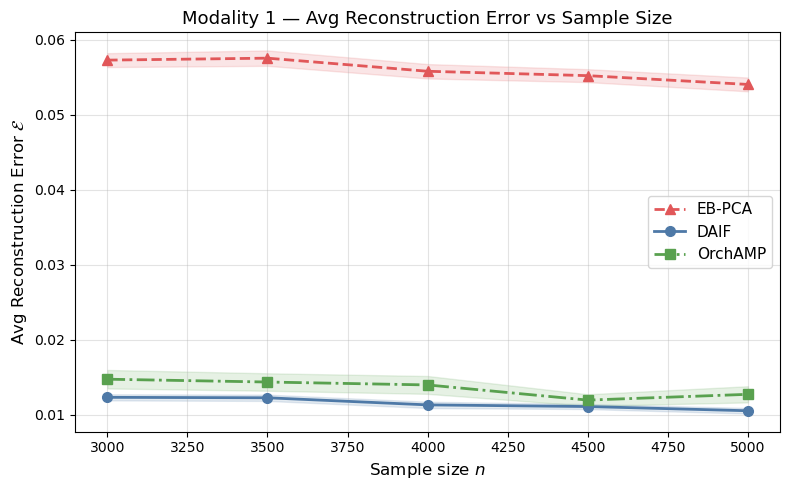

Saved ../Plots/modality_1_rec_error_vs_n.png


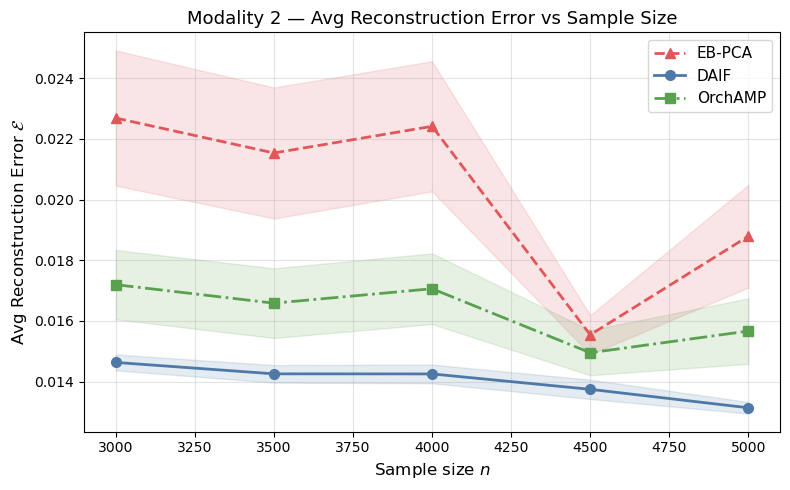

Saved ../Plots/modality_2_rec_error_vs_n.png


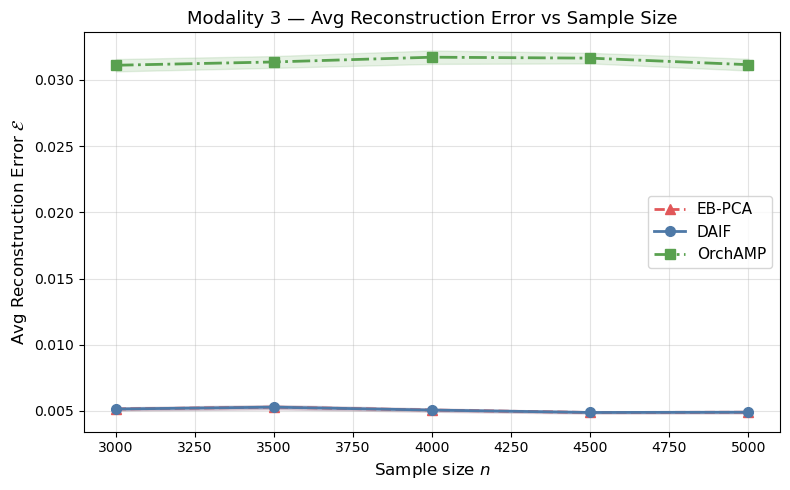

Saved ../Plots/modality_3_rec_error_vs_n.png


In [10]:
# ---------------------------------------------------------------
# Plots — mean line with SE shaded band
# ---------------------------------------------------------------
METHOD_STYLES = {
    'EB-PCA':  {'marker': '^', 'linestyle': '--', 'color': '#E15759'},
    'DAIF':    {'marker': 'o', 'linestyle': '-',  'color': '#4E79A7'},
    'OrchAMP': {'marker': 's', 'linestyle': '-.', 'color': '#59A14F'},
}

for mod_idx in range(NUM_MODALITIES):
    fig, ax = plt.subplots(figsize=(8, 5))

    for strategy, label in STRATEGY_LABELS.items():
        means = [summary[n][strategy]['mean'][mod_idx] for n in n_values_present]
        ses   = [summary[n][strategy]['se'][mod_idx]   for n in n_values_present]
        means = np.array(means)
        ses   = np.array(ses)
        style = METHOD_STYLES[label]

        ax.plot(
            n_values_present, means,
            label=label,
            marker=style['marker'], linestyle=style['linestyle'],
            color=style['color'], linewidth=2, markersize=7
        )
        # Shaded SE band
        ax.fill_between(
            n_values_present,
            means - ses, means + ses,
            color=style['color'], alpha=0.15
        )

    ax.set_title(
        f'Modality {mod_idx + 1} — Avg Reconstruction Error vs Sample Size',
        fontsize=13
    )
    ax.set_xlabel('Sample size $n$', fontsize=12)
    ax.set_ylabel(r'Avg Reconstruction Error $\mathcal{E}$', fontsize=12)
    ax.grid(True, alpha=0.35)
    ax.legend(fontsize=11)
    fig.tight_layout()

    path = os.path.join(PLOTS_DIR, f'modality_{mod_idx+1}_rec_error_vs_n.png')
    fig.savefig(path, dpi=150)
    plt.show()
    print(f'Saved {path}')
